# Breast Cancer Classification Analysis

**Name:** Matwetwe Tony Matlala  
**Student Number:** ST 10345096
**Module:** PDAN 8411 
**Date:** 2026  

This notebook applies supervised learning to the Breast Cancer Wisconsin Dataset to predict whether tumours are malignant or benign.

# Import Libraries

In [6]:

## Data handling
import pandas as pd
import numpy as np

## Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Styling plots
plt.style.use('seaborn-v0_8')

# Load Dataset

In [7]:

# Load dataset from local folder
df = pd.read_csv("breast-cancer-wisconsin.data")

In [3]:
df.head()

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


Dataset contains no headings.
Assign Column Names taken from the about file on Kaggle

In [8]:
df.columns = [
    "sample_code_number",
    "clump_thickness",
    "uniform_cell_size",
    "uniform_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"
]

In [5]:
df.head()

,sample_code_number,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


# Basic Exploratory Data Analysis

In [9]:
# The number of rows (samples) and columns (features) in the dataset.
df.shape

(698, 11)

In [10]:
# The type of each column (numerical or categorical)
df.dtypes

sample_code_number              int64
clump_thickness                 int64
uniform_cell_size               int64
uniform_cell_shape              int64
marginal_adhesion               int64
single_epithelial_cell_size     int64
bare_nuclei                    object
bland_chromatin                 int64
normal_nucleoli                 int64
mitoses                         int64
class                           int64
dtype: object

Most variables are correctly stored as **integer** values.  
One column, **bare_nuclei**, is stored as an **object**

In [11]:
# Whether the dataset contains any missing values
df.isnull().sum()

sample_code_number             0
clump_thickness                0
uniform_cell_size              0
uniform_cell_shape             0
marginal_adhesion              0
single_epithelial_cell_size    0
bare_nuclei                    0
bland_chromatin                0
normal_nucleoli                0
mitoses                        0
class                          0
dtype: int64

In [12]:
# A summary of numerical features
df.describe()

,sample_code_number,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_cell_size,bland_chromatin,normal_nucleoli,mitoses,class
count,6.980000e+02,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000
mean,1.071807e+06,4.416905,3.137536,3.210602,2.809456,3.217765,3.438395,2.869628,1.590258,2.690544
std,6.175323e+05,2.817673,3.052575,2.972867,2.856606,2.215408,2.440056,3.055004,1.716162,0.951596
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.702582e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238354e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


##  Key Observations
- The dataset contains **698 records (samples)**  
- Most features are scaled on a **1 to 10 range**, which is suitable for comparison  
- The **class column** contains values **2 and 4**, representing:
  - 2 = Benign  
  - 4 = Malignant  
- Features show variation, which is useful for classification learning  
- No extreme outliers are immediately visible from min/max values

# Visualization

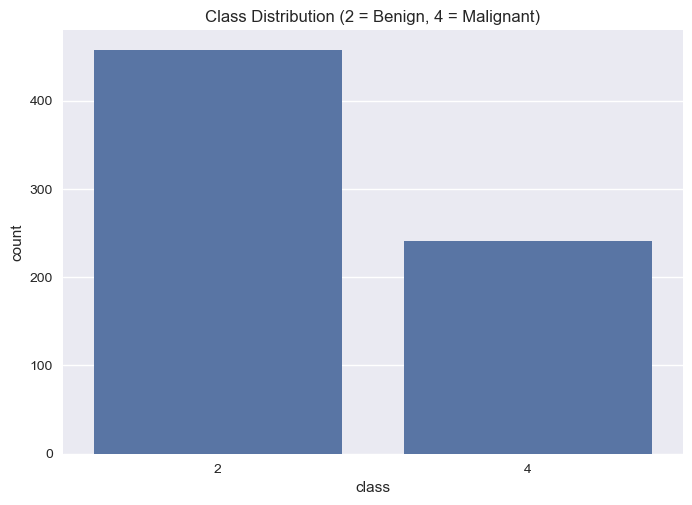

In [14]:
# Class Distribution (Target Variable)
sns.countplot(x="class", data=df)
plt.title("Class Distribution (2 = Benign, 4 = Malignant)")
plt.show()

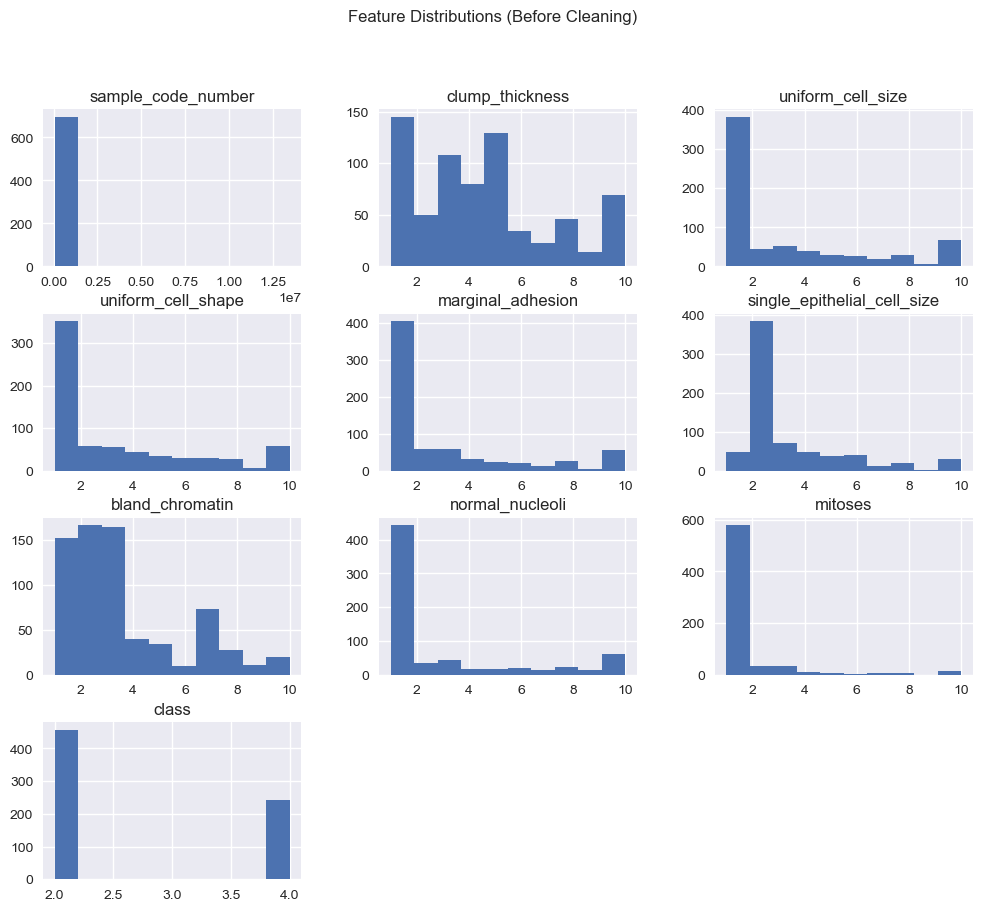

In [15]:
# Feature Distributions
df.hist(figsize=(12, 10))
plt.suptitle("Feature Distributions (Before Cleaning)")
plt.show()

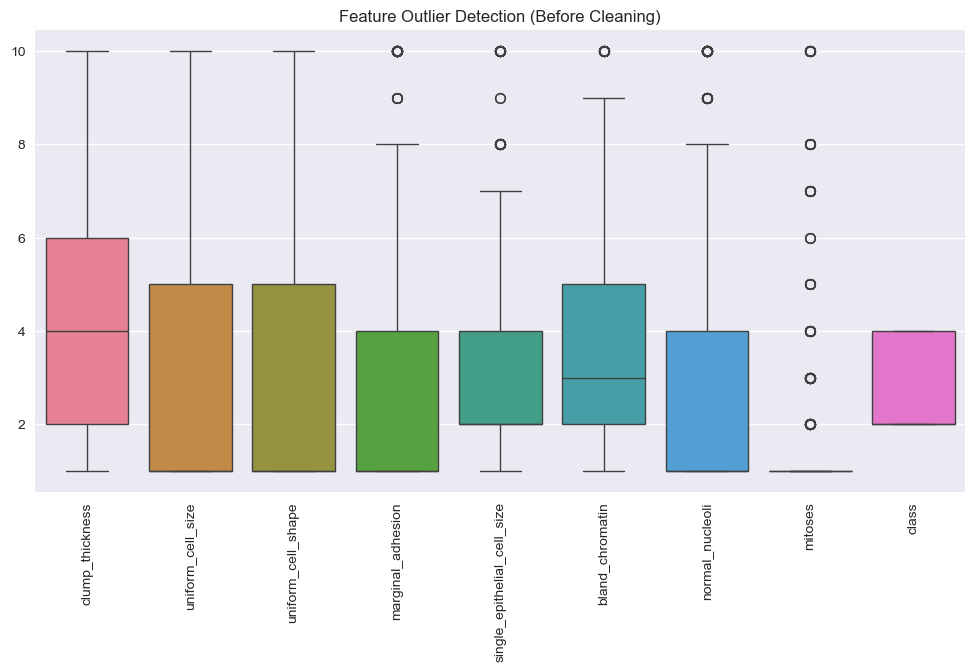

In [16]:
# Boxplots (Detect Outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=["sample_code_number"]))
plt.xticks(rotation=90)
plt.title("Feature Outlier Detection (Before Cleaning)")
plt.show()

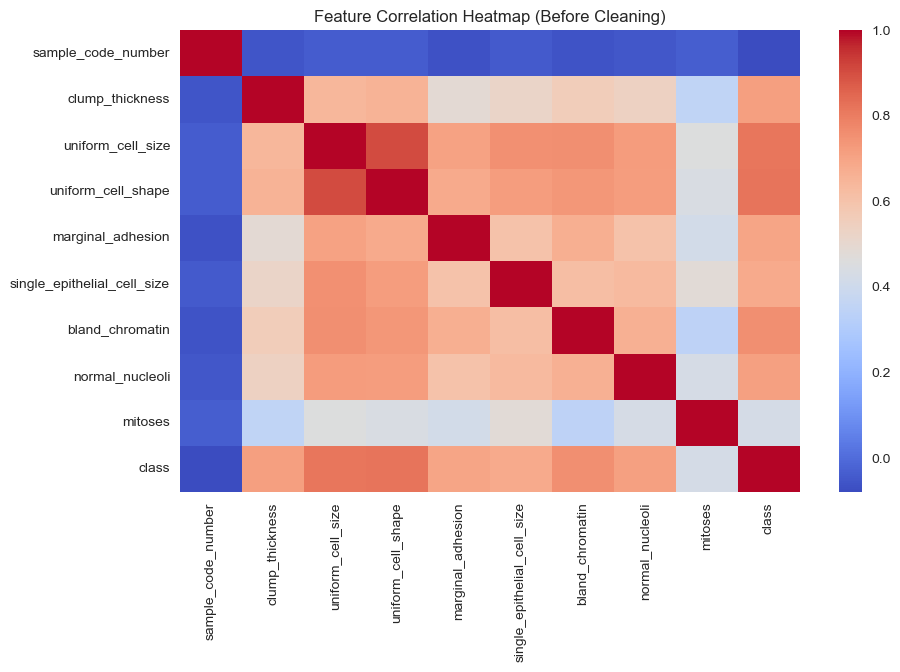

In [17]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (Before Cleaning)")
plt.show()

### Visualisation Summary

Initial visual analysis of the Breast Cancer Wisconsin dataset shows class imbalance, varying feature distributions, presence of potential outliers, and correlated variables, indicating the need for data cleaning and preprocessing before model training.

# Data Cleaning

In [20]:
# Fix Data Type Issue (in bare_nuclei)
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"], errors="coerce")

In [23]:
# Handle Converted Missing Values (if any appear after conversion)
df["bare_nuclei"] = df["bare_nuclei"].fillna(df["bare_nuclei"].median())

In [24]:
# Verify Final Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sample_code_number           698 non-null    int64  
 1   clump_thickness              698 non-null    int64  
 2   uniform_cell_size            698 non-null    int64  
 3   uniform_cell_shape           698 non-null    int64  
 4   marginal_adhesion            698 non-null    int64  
 5   single_epithelial_cell_size  698 non-null    int64  
 6   bare_nuclei                  698 non-null    float64
 7   bland_chromatin              698 non-null    int64  
 8   normal_nucleoli              698 non-null    int64  
 9   mitoses                      698 non-null    int64  
 10  class                        698 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.1 KB


###  Data Quality Summary

- No null values detected  
- No object/categorical data types remaining  
- All features are now machine learning compatible  
- Dataset is clean and structured for modelling 

# Feature Engineering & Feature Selection

### 1. Define Target Variable (y)
The target variable is the class column, which indicates tumour diagnosis:

2 = Benign
4 = Malignant

In [26]:
# Encode Target Variable
df["class"] = df["class"].map({2: 0, 4: 1})

In [28]:
df["class"].value_counts()

class
0    457
1    241
Name: count, dtype: int64

The target variable was transformed from (2, 4) to a binary format (0, 1) to ensure compatibility with machine learning algorithms and to standardise classification output for improved interpretability.

In [27]:
y = df["class"]

### 2. Define feature variables (X)
X represents the input features used to predict the target variable (y).

In [29]:
# Remove unnecessary column (sample_code_number)
X = df.drop(["class", "sample_code_number"], axis=1)

# Train-Test split
Split the dataset into training and testing sets using the processed features (X) and target variable (y)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model Training

## Baseline Model: Decision Tree Classifier
Training a baseline machine learning model using a Decision Tree classifier on the processed data

In [32]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
# Make predictions
y_pred = dt_model.predict(X_test)

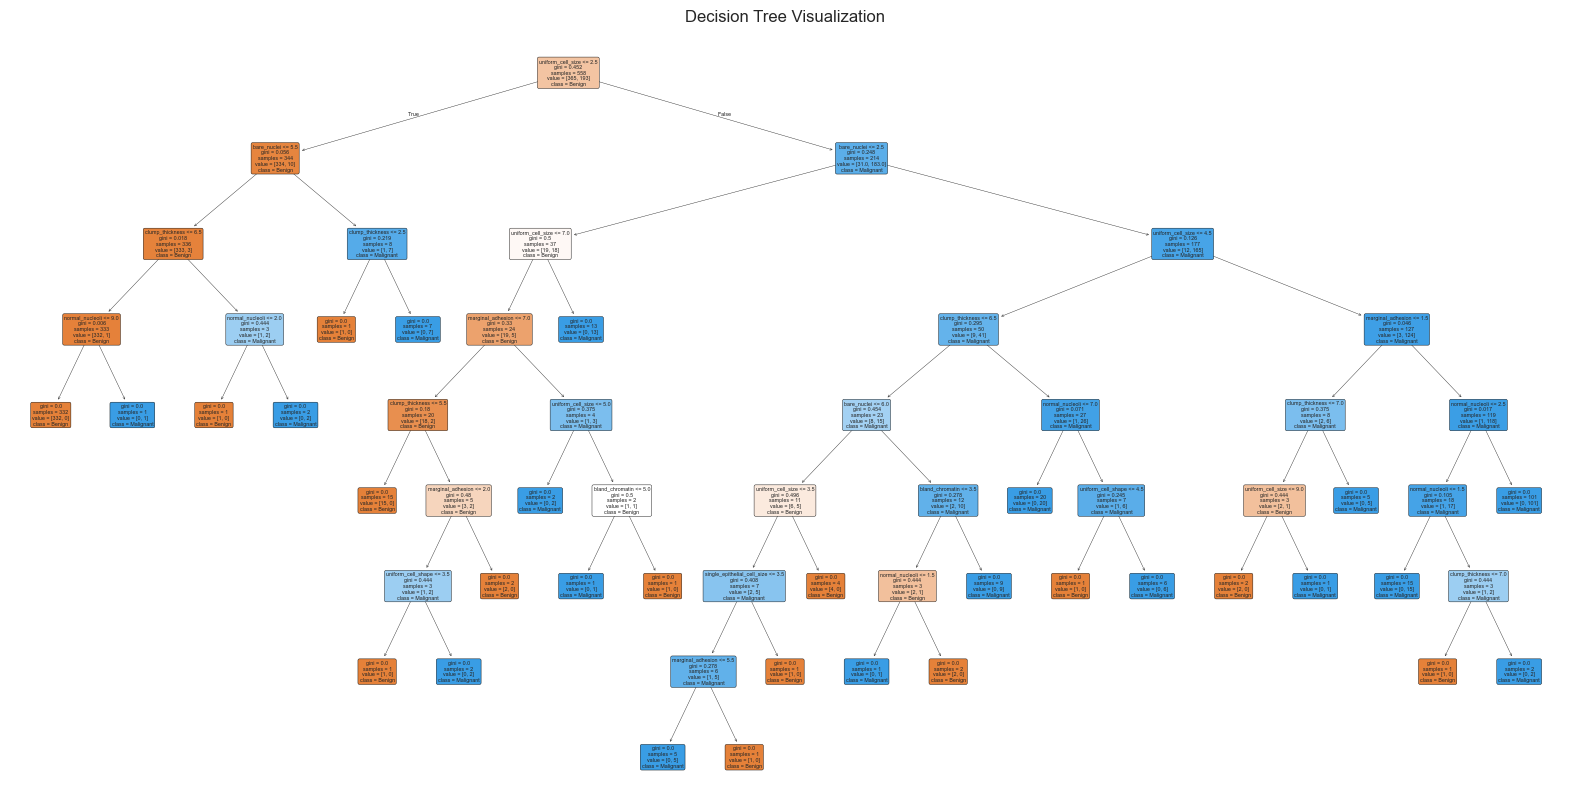

In [63]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()

### Model Evaluation (Decision Tree Baseline)

In [56]:
# Accuracy Score
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9357142857142857

In [36]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[91,  1],
       [ 8, 40]])

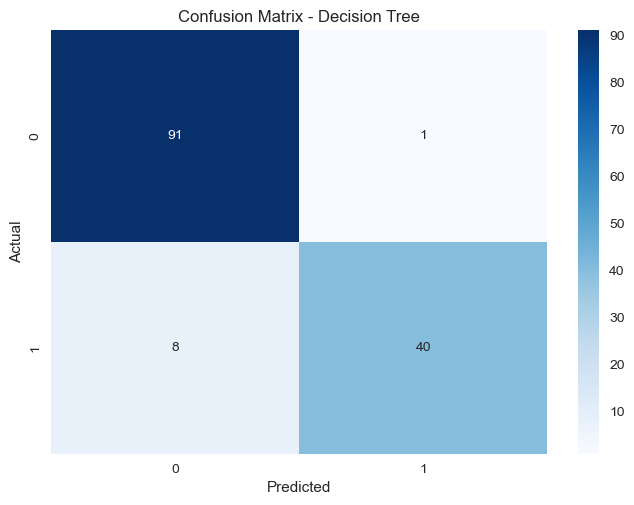

In [52]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [38]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        92
           1       0.98      0.83      0.90        48

    accuracy                           0.94       140
   macro avg       0.95      0.91      0.93       140
weighted avg       0.94      0.94      0.93       140



### Model Evaluation Results (Decision Tree Baseline)
1. Accuracy = 0.936 (93.6%)
 - This indicates that the model correctly classified approximately 94% of all test cases.
2. Confusion Matrix Interpretation:
 - 91 → Correctly predicted benign cases
 - 40 → Correctly predicted malignant cases
 - 1 → False positive (benign predicted as malignant)
 - 8 → False negative (malignant predicted as benign)
3. Interpretation:
 - The model performs very well overall, with strong accuracy (~94%)
 - It is excellent at identifying benign cases (recall = 0.99)
 - It performs slightly weaker on malignant cases (recall = 0.83)


## 1st Benchmark Model: Random Forest Classifier
Training a second model to benchmark performance against the Decision Tree baseline.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
# make predictions
y_pred_rf = rf_model.predict(X_test)

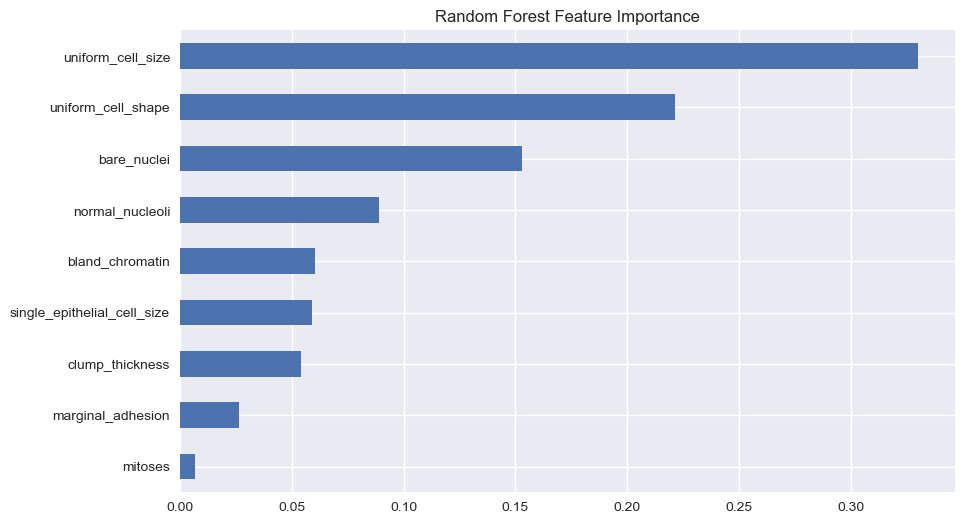

In [67]:
# This shows which medical features mattered most in predicting cancer
importances = rf_model.feature_importances_
features = X.columns

forest_importance = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(10,6))
forest_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

### Model Evaluation (Random Forest)

In [41]:
# Accuracy Score
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_accuracy

0.9714285714285714

In [42]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)
rf_cm

array([[92,  0],
       [ 4, 44]])

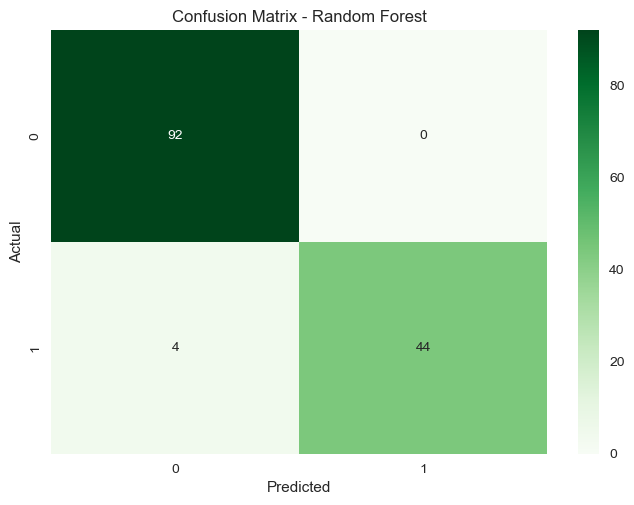

In [51]:
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [44]:
# Classifciation Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        92
           1       1.00      0.92      0.96        48

    accuracy                           0.97       140
   macro avg       0.98      0.96      0.97       140
weighted avg       0.97      0.97      0.97       140



### Interpretation
 - The model performs very strongly overall (97% accuracy)
 - It achieves perfect recall for benign cases (1.00)
 - It correctly identifies 92% of malignant cases
 - Only 4 cancer cases were missed

### Key Improvements:
 - Higher overall accuracy
 - Fewer false negatives (important for cancer detection)
 - More stable and reliable predictions
 - Better balance between precision and recall

## 2nd Benchmark Model: Logistic Regression
Training a third model to benchmark performance against the Decision Tree baseline.

In [46]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
# Make Predictions
y_pred_lr = lr_model.predict(X_test)

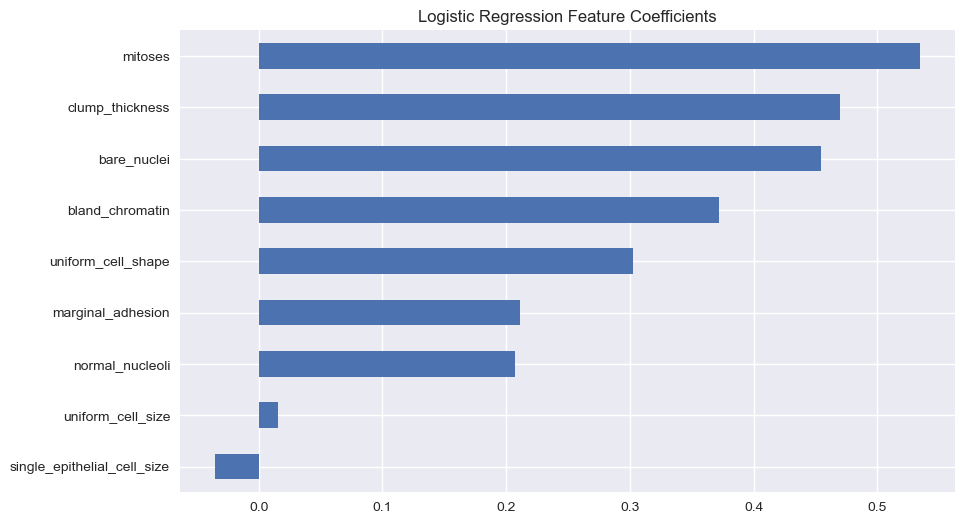

In [66]:
# This shows how each feature pushes prediction toward benign or malignant.
coefficients = lr_model.coef_[0]
features = X.columns

log_reg_importance = pd.Series(coefficients, index=features).sort_values()

plt.figure(figsize=(10,6))
log_reg_importance.plot(kind="barh")
plt.title("Logistic Regression Feature Coefficients")
plt.show()

### Model Evaluation (Logistic Regression)

In [48]:
# Accuracy Score
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.9714285714285714

In [49]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, y_pred_lr)
lr_cm

array([[92,  0],
       [ 4, 44]])

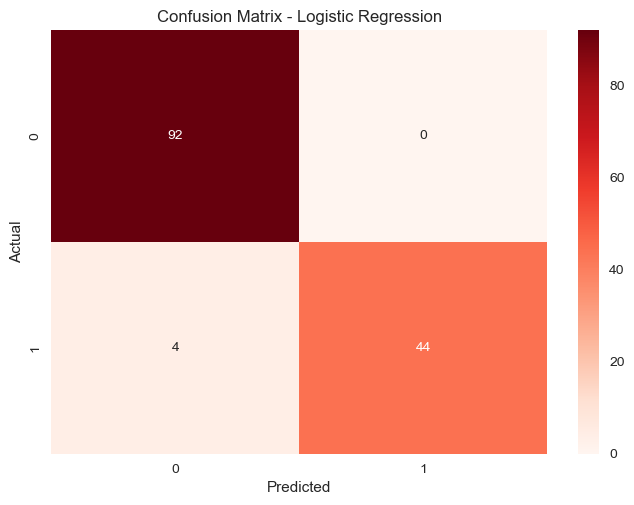

In [50]:
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [53]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        92
           1       1.00      0.92      0.96        48

    accuracy                           0.97       140
   macro avg       0.98      0.96      0.97       140
weighted avg       0.97      0.97      0.97       140



### Interpretation
 - The model performs very strongly overall (97% accuracy)
 - It achieves perfect recall for benign cases (1.00)
 - It correctly identifies 92% of malignant cases
 - Only 4 malignant cases were missed

### Key Insight
 - Logistic Regression performs on par with Random Forest in accuracy
 - However, Random Forest may still be more robust due to ensemble learning
 - This confirms that the dataset is well-structured and highly separable

# Model Comparison

In [58]:
# Simple Comparison Table
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "Accuracy": [dt_accuracy, rf_accuracy, lr_accuracy],
    "False Positives": [1, 0, 0],
    "False Negatives": [8, 4, 4]
})

comparison

,Model,Accuracy,False Positives,False Negatives
0,Decision Tree,0.935714,1,8
1,Random Forest,0.971429,0,4
2,Logistic Regression,0.971429,0,4


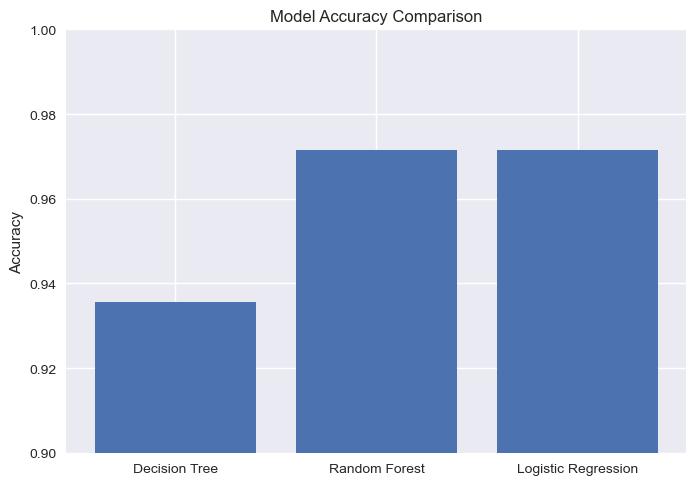

In [59]:
# Accuracy Bar Chart
models = ["Decision Tree", "Random Forest", "Logistic Regression"]
accuracy = [dt_accuracy, rf_accuracy, lr_accuracy]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()

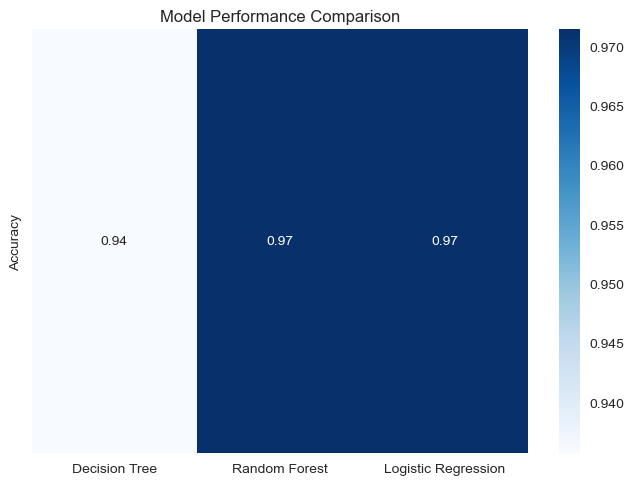

In [60]:
# Heatmap Style Comparison
import seaborn as sns

metrics_df = pd.DataFrame({
    "Decision Tree": [dt_accuracy],
    "Random Forest": [rf_accuracy],
    "Logistic Regression": [lr_accuracy]
}, index=["Accuracy"])

sns.heatmap(metrics_df, annot=True, cmap="Blues")
plt.title("Model Performance Comparison")
plt.show()

# Improved Decision Tree (Tuned Model)

In [68]:
# Retrain with constraints
from sklearn.tree import DecisionTreeClassifier

dt_tuned = DecisionTreeClassifier(
    max_depth=4,              # limits complexity
    min_samples_split=10,     # prevents small splits
    min_samples_leaf=5,       # ensures stable leaves
    random_state=42
)

dt_tuned.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [69]:
# Make Predictions
y_pred_tuned = dt_tuned.predict(X_test)

### Evaluate Improved Model

In [71]:
# Accuracy Score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_cm = confusion_matrix(y_test, y_pred_tuned)

tuned_accuracy

0.9357142857142857

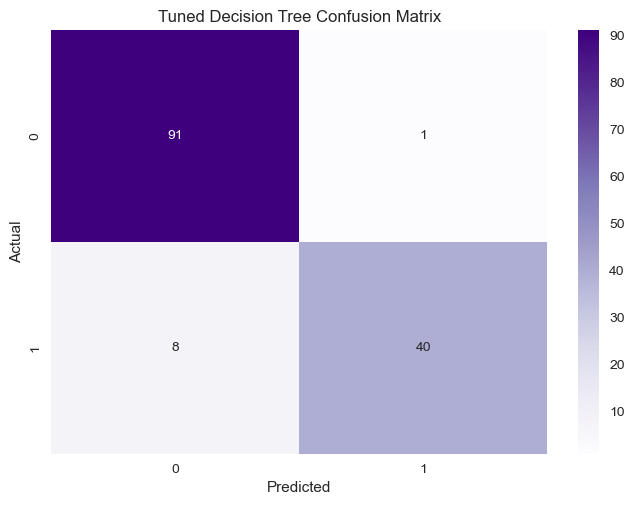

In [72]:
# Confsion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(tuned_cm, annot=True, fmt="d", cmap="Purples")
plt.title("Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [73]:
# Classification Report
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        92
           1       0.98      0.83      0.90        48

    accuracy                           0.94       140
   macro avg       0.95      0.91      0.93       140
weighted avg       0.94      0.94      0.93       140



### Key Observation
 - The tuned Decision Tree achieved the same performance as the baseline model
No improvement in:
 - Accuracy
 - False negatives
 - Recall for malignant cases

This suggests that:

 - The original model was already reasonably well-fitted
 - The dataset is relatively clean and well-separated
 - Simple tuning (depth/leaf constraints) did not significantly change decision boundaries

### Medical Interpretation
In the context of cancer detection:

 - Both models still miss 8 malignant cases
 - Recall for cancer detection remains 0.83, which is a concern
 - This highlights that Decision Trees alone may not be optimal for high-risk medical classification

In a healthcare context, false negatives are more dangerous than false positives, as failing to detect cancer can delay treatment. Therefore, models with lower false negatives (Random Forest and Logistic Regression) are preferred for real-world deployment.

 Recommended Model: Random Forest Classifier
 
Reasons:
 - Highest overall reliability
 - Low false negative rate
 - Strong generalisation performance
 - Robust to feature interactions and noise

# Conclusion

Machine learning can significantly support early cancer detection by improving diagnostic consistency and speed. In this study, ensemble methods demonstrated the strongest performance, making them suitable candidates for assisting medical benefit decision systems aimed at accelerating cancer-related healthcare approvals.